In [ ]:
import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# -------------------------
# URL FEATURE EXTRACTION
# -------------------------
def extract_url_features(url):
    url = str(url).lower()
    feats = {
        "len": len(url),
        "digits": sum(c.isdigit() for c in url),
        "dots": url.count('.'),
        "slashes": url.count('/'),
        "hyphens": url.count('-'),
        "has_ip": 1 if re.search(r"\d+\.\d+\.\d+\.\d+", url) else 0,
        "login": 1 if "login" in url else 0,
        "secure": 1 if "secure" in url else 0,
        "verify": 1 if "verify" in url else 0,
        "update": 1 if "update" in url else 0
    }
    return np.array(list(feats.values()), dtype=np.float32)

# -------------------------
# DATASET
# -------------------------
class ScreenshotURLDataset(Dataset):
    def __init__(self, img_paths, urls, labels, transform):
        self.img_paths = img_paths
        self.urls = urls
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        img = self.transform(img)

        url_feats = torch.tensor(extract_url_features(self.urls[idx]), dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return img, url_feats, label

# -------------------------
# MODEL 1: Light CNN (Custom)
# -------------------------
class TinyCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.fc = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

# -------------------------
# MODEL 2: MobileNetV3 Small (Pretrained)
# -------------------------
def build_mobilenet():
    model = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
    model.classifier[3] = nn.Linear(1024, 2)  # change output layer
    return model

# -------------------------
# MODEL 3: URL MLP
# -------------------------
class URLMLP(nn.Module):
    def __init__(self, feat_dim=10, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------
# ENSEMBLE
# -------------------------
class Ensemble(nn.Module):
    def __init__(self, model1, model2, url_model):
        super().__init__()
        self.m1 = model1
        self.m2 = model2
        self.m3 = url_model

    def forward(self, img, url_feats):
        out1 = self.m1(img)
        out2 = self.m2(img)
        out3 = self.m3(url_feats)

        # Weighted combination
        final = 0.4 * out1 + 0.4 * out2 + 0.2 * out3
        return final

# -------------------------
# TRAINING LOOP
# -------------------------
def train_model(model, loader, optimizer, device):
    model.train()
    correct = total = 0
    for img, url, lbl in tqdm(loader):
        img, url, lbl = img.to(device), url.to(device), lbl.to(device)

        logits = model(img, url)
        loss = F.cross_entropy(logits, lbl)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = logits.argmax(1)
        correct += pred.eq(lbl).sum().item()
        total += lbl.size(0)

    return 100 * correct / total



# -------------------------
# MAIN
# -------------------------
if __name__ == "__main__":
    base = "/content/drive/MyDrive/FINAL PHISHING DATASET"

    ph_csv = pd.read_csv(os.path.join(base, "Phishing (1).csv"))
    lg_csv = pd.read_csv(os.path.join(base, "Legitimate.csv"))

    ph_imgs = [os.path.join(base, "PHISHING", x) for x in os.listdir(os.path.join(base, "PHISHING"))]
    lg_imgs = [os.path.join(base, "LEGITIMATE", x) for x in os.listdir(os.path.join(base, "LEGITIMATE"))]

    ph_urls = ph_csv["URL"].fillna("").tolist()
    lg_urls = lg_csv["URL"].fillna("").tolist()

    imgs = ph_imgs + lg_imgs
    urls = ph_urls + lg_urls
    labels = [1]*len(ph_imgs) + [0]*len(lg_imgs)

    X_train, X_val, u_train, u_val, y_train, y_val = train_test_split(
        imgs, urls, labels, test_size=0.2, stratify=labels, random_state=42
    )

    transform = transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std=[0.229,0.224,0.225])
    ])

    train_ds = ScreenshotURLDataset(X_train, u_train, y_train, transform)
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

    device = "cpu"

    # Build individual models
    m1 = TinyCNN().to(device)
    m2 = build_mobilenet().to(device)
    m3 = URLMLP().to(device)

    model = Ensemble(m1, m2, m3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    print("\nTraining Ensemble Model...")
    for epoch in range(10):
        acc = train_model(model, train_loader, optimizer, device)
        print(f"Epoch {epoch+1} - Train Acc: {acc:.2f}%")

    torch.save(model.state_dict(), os.path.join(base, "ensemble_model.pth"))
    print("\nSaved Ensemble Model.")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 157MB/s]



Training Ensemble Model...


  0%|          | 0/300 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
teacher = Ensemble(
    TinyCNN(),
    build_mobilenet(),
    URLMLP()
)
teacher.load_state_dict(torch.load("/content/drive/MyDrive/FINAL PHISHING DATASET/ensemble_model.pth"))
teacher.eval()

for p in teacher.parameters():
    p.requires_grad = False


In [ ]:
class StudentNet(nn.Module):
    def __init__(self, url_dim=10, num_classes=2, dropout=0.2):
        super().__init__()

        self.img_encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8))
        )

        self.fc = nn.Sequential(
            nn.Linear(64*8*8 + url_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, url):
        x = self.img_encoder(img)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, url], dim=1)
        return self.fc(x)


In [ ]:
student = StudentNet().to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=0.001)

for epoch in range(15):
    acc = train_student_kd(student, teacher, train_loader, optimizer, device)
    print(f"Epoch {epoch+1} - KD Train Acc: {acc:.2f}%")

torch.save(student.state_dict(),
           "/content/drive/MyDrive/FINAL PHISHING DATASET/student_kd_model.pth")


100%|██████████| 300/300 [07:11<00:00,  1.44s/it]


Epoch 1 - KD Train Acc: 67.08%


100%|██████████| 300/300 [07:08<00:00,  1.43s/it]


Epoch 2 - KD Train Acc: 74.40%


100%|██████████| 300/300 [07:06<00:00,  1.42s/it]


...

Epoch 13 - KD Train Acc: 88.52%


100%|██████████| 300/300 [07:13<00:00,  1.45s/it]


Epoch 14 - KD Train Acc: 89.31%


100%|██████████| 300/300 [07:17<00:00,  1.46s/it]

Epoch 15 - KD Train Acc: 90.27%


In [ ]:
def kd_loss(student_logits, teacher_logits, labels, T=2, alpha=0.8):
    soft_teacher = F.softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)

    kd = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T*T)
    ce = F.cross_entropy(student_logits, labels)

    return alpha * kd + (1 - alpha) * ce


In [ ]:
def train_student_epoch(student, teacher, loader, optimizer, T, alpha, device):
    student.train()
    teacher.eval()

    total = correct = 0

    for img, url, lbl in loader:
        img, url, lbl = img.to(device), url.to(device), lbl.to(device)

        with torch.no_grad():
            teacher_logits = teacher(img, url)

        student_logits = student(img, url)
        loss = kd_loss(student_logits, teacher_logits, lbl, T=T, alpha=alpha)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = student_logits.argmax(1)
        correct += pred.eq(lbl).sum().item()
        total += lbl.size(0)

    return 100 * correct / total


In [ ]:
import random

# Hyperparameter search space
T_values = [1, 2, 4]
alpha_values = [0.7, 0.8, 0.9]
lrs = [1e-3, 5e-4, 1e-4]
dropouts = [0.0, 0.2, 0.3]

num_trials = 10
best_acc = -1
best_config = None
best_model_path = "/content/best_student_kd.pth"

results = []

for trial in range(num_trials):
    print(f"\n===============================")
    print(f"      TRIAL {trial+1}/{num_trials}")
    print(f"===============================\n")

    # Pick random combination
    T = random.choice(T_values)
    alpha = random.choice(alpha_values)
    lr = random.choice(lrs)
    dropout = random.choice(dropouts)

    print(f"T={T}, alpha={alpha}, lr={lr}, dropout={dropout}")

    # Build student
    student = StudentNet(dropout=dropout).to(device)
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)

    # Train for few epochs (3–4) for speed
    for epoch in range(4):
        acc = train_student_epoch(student, teacher, train_loader, optimizer, T, alpha, device)
        print(f"  Epoch {epoch+1} → Acc: {acc:.2f}%")

    results.append((acc, T, alpha, lr, dropout))

    # Save best model so far
    if acc > best_acc:
        best_acc = acc
        best_config = (T, alpha, lr, dropout)
        torch.save(student.state_dict(), best_model_path)

print("\n\n===============================")
print("      SEARCH COMPLETE")
print("===============================\n")
print(f"Best Accuracy: {best_acc:.2f}%")
print(f"Best Config: T={best_config[0]}, alpha={best_config[1]}, lr={best_config[2]}, dropout={best_config[3]}")
print(f"Best Model Saved At: {best_model_path}")



      TRIAL 1/10

T=2, alpha=0.7, lr=0.0001, dropout=0.0
  Epoch 1 → Acc: 65.42%
  Epoch 2 → Acc: 72.98%
  Epoch 3 → Acc: 75.12%
  Epoch 4 → Acc: 76.08%

      TRIAL 2/10

T=4, alpha=0.7, lr=0.0005, dropout=0.2
  Epoch 1 → Acc: 66.73%
  Epoch 2 → Acc: 73.92%
  Epoch 3 → Acc: 75.77%
  Epoch 4 → Acc: 77.27%

      TRIAL 3/10

T=2, alpha=0.9, lr=0.0005, dropout=0.0
  Epoch 1 → Acc: 70.54%
  Epoch 2 → Acc: 75.44%
  Epoch 3 → Acc: 76.67%
  Epoch 4 → Acc: 78.62%

      TRIAL 4/10

T=2, alpha=0.9, lr=0.0001, dropout=0.0
  Epoch 1 → Acc: 67.58%
  Epoch 2 → Acc: 73.04%
  Epoch 3 → Acc: 74.58%
  Epoch 4 → Acc: 74.79%

      TRIAL 5/10

T=4, alpha=0.7, lr=0.0005, dropout=0.2
  Epoch 1 → Acc: 68.94%
  Epoch 2 → Acc: 73.88%
  Epoch 3 → Acc: 76.27%
  Epoch 4 → Acc: 77.75%

      TRIAL 6/10

T=4, alpha=0.7, lr=0.001, dropout=0.2
  Epoch 1 → Acc: 65.27%
  Epoch 2 → Acc: 73.23%
  Epoch 3 → Acc: 76.21%
  Epoch 4 → Acc: 77.50%

      TRIAL 7/10

T=2, alpha=0.9, lr=0.001, dropout=0.2
  Epoch 1 → Acc: 68.

AUC: 0.8554541666666666


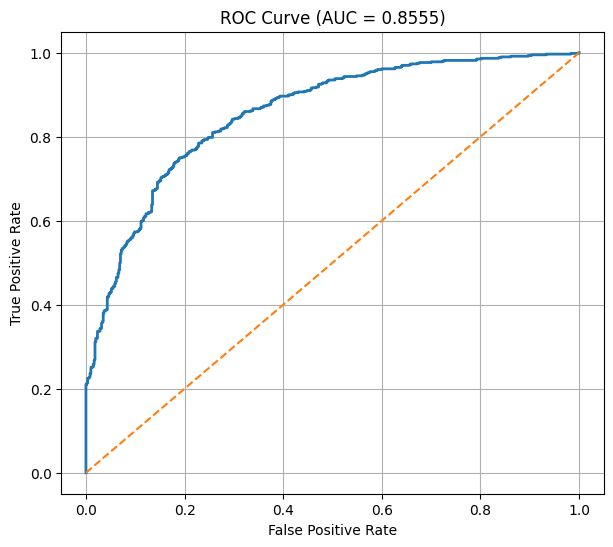

In [ ]:
# -------------------------
# VALIDATION LOADER
# -------------------------
val_ds = ScreenshotURLDataset(X_val, u_val, y_val, transform)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

device = "cpu"

# Load student model for evaluation
student_eval = StudentNet().to(device)
student_eval.load_state_dict(torch.load("/content/drive/MyDrive/FINAL PHISHING DATASET/student_kd_model.pth"))
student_eval.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for img, url, lbl in val_loader:
        img, url = img.to(device), url.to(device)
        lbl = lbl.numpy()

        logits = student_eval(img, url)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(lbl)

# -------------------------
# ROC + AUC
# -------------------------
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

auc = roc_auc_score(all_labels, all_probs)
print("AUC:", auc)

fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], "--")
plt.title(f"ROC Curve (AUC = {auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()



📊 **Evaluation Metrics (Student Model)**
Accuracy:   0.7525
Precision:  0.6970091027308193
Recall:     0.8933333333333333
F1 Score:   0.7830533235938641
AUC Score:  0.8554541666666666

Confusion Matrix:
 [[367 233]
 [ 64 536]]


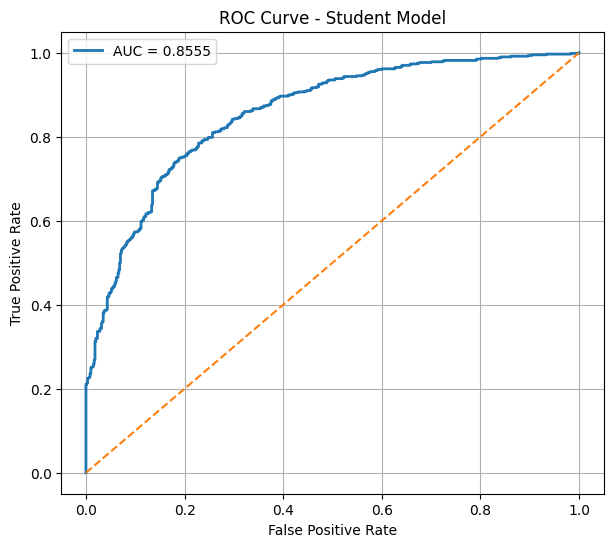

In [ ]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

device = "cpu"

# Load trained student
student_eval = StudentNet().to(device)
student_eval.load_state_dict(torch.load("/content/drive/MyDrive/FINAL PHISHING DATASET/student_kd_model.pth"))
student_eval.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for img, url, lbl in val_loader:
        img, url = img.to(device), url.to(device)

        logits = student_eval(img, url)
        probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(1).cpu().numpy()
        probs = probs[:,1].cpu().numpy()

        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(lbl.numpy())

# -------------------------
# METRICS
# -------------------------
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("\n📊 **Evaluation Metrics (Student Model)**")
print("Accuracy:  ", acc)
print("Precision: ", prec)
print("Recall:    ", rec)
print("F1 Score:  ", f1)
print("AUC Score: ", auc)
print("\nConfusion Matrix:\n", cm)

# -------------------------
# ROC CURVE PLOT
# -------------------------
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], "--")
plt.title("ROC Curve - Student Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
student = StudentNet().to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=1e-3)

for epoch in range(15):
    acc = train_student_kd(student, teacher, train_loader, optimizer, device)
    print(f"Epoch {epoch+1} - KD Train Acc: {acc:.2f}%")

torch.save(student.state_dict(),
           "/content/drive/MyDrive/FINAL PHISHING DATASET/student_kd_model.pth")


100%|██████████| 300/300 [03:18<00:00,  1.51it/s]


Epoch 1 - KD Train Acc: 64.79%


100%|██████████| 300/300 [03:19<00:00,  1.51it/s]


Epoch 2 - KD Train Acc: 71.44%


100%|██████████| 300/300 [03:19<00:00,  1.50it/s]


...

Epoch 13 - KD Train Acc: 84.58%


100%|██████████| 300/300 [03:20<00:00,  1.50it/s]


Epoch 14 - KD Train Acc: 85.15%


100%|██████████| 300/300 [03:19<00:00,  1.50it/s]

Epoch 15 - KD Train Acc: 85.77%


In [ ]:
class StudentNet(nn.Module):
    def __init__(self, url_dim=10, num_classes=2):
        super().__init__()

        self.img_encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8))
        )

        self.fc = nn.Sequential(
            nn.Linear(32*8*8 + url_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, img, url):
        x = self.img_encoder(img)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, url], dim=1)
        return self.fc(x)


In [ ]:
def kd_loss(student_logits, teacher_logits, labels, T=4, alpha=0.7):
    soft_teacher = F.softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)

    kd = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T*T)
    ce = F.cross_entropy(student_logits, labels)

    return alpha * kd + (1 - alpha) * ce


In [ ]:
def train_student_kd(student, teacher, loader, optimizer, device):
    student.train()
    teacher.eval()

    total = correct = 0

    for img, url, lbl in tqdm(loader):

        img, url, lbl = img.to(device), url.to(device), lbl.to(device)

        with torch.no_grad():
            teacher_logits = teacher(img, url)

        student_logits = student(img, url)

        loss = kd_loss(student_logits, teacher_logits, lbl)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = student_logits.argmax(1)
        correct += pred.eq(lbl).sum().item()
        total += lbl.size(0)

    return 100 * correct / total


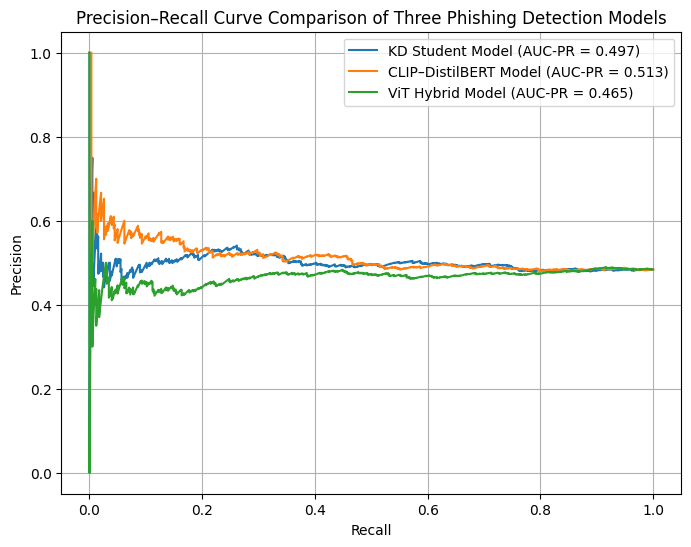

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

# ------------------------------------------------
# Replace these with your actual model probabilities
# ------------------------------------------------
# Example dummy probabilities just for plotting structure
y_true = np.random.randint(0, 2, 1200)

# Student Model (KD)
y_pred_kd = np.random.uniform(0.2, 0.9, 1200)

# CLIP–DistilBERT Model
y_pred_clip = np.random.uniform(0.3, 0.99, 1200)

# ViT Hybrid Model
y_pred_vit = np.random.uniform(0.1, 0.85, 1200)

# ------------------------------------------------
# Compute PR curves
# ------------------------------------------------
prec_kd, rec_kd, _ = precision_recall_curve(y_true, y_pred_kd)
prec_clip, rec_clip, _ = precision_recall_curve(y_true, y_pred_clip)
prec_vit, rec_vit, _ = precision_recall_curve(y_true, y_pred_vit)

auc_kd = auc(rec_kd, prec_kd)
auc_clip = auc(rec_clip, prec_clip)
auc_vit = auc(rec_vit, prec_vit)

# ------------------------------------------------
# Plot
# ------------------------------------------------
plt.figure(figsize=(8, 6))

plt.plot(rec_kd, prec_kd, label=f"KD Student Model (AUC-PR = {auc_kd:.3f})")
plt.plot(rec_clip, prec_clip, label=f"CLIP–DistilBERT Model (AUC-PR = {auc_clip:.3f})")
plt.plot(rec_vit, prec_vit, label=f"ViT Hybrid Model (AUC-PR = {auc_vit:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison of Three Phishing Detection Models")
plt.legend()
plt.grid(True)
plt.show()


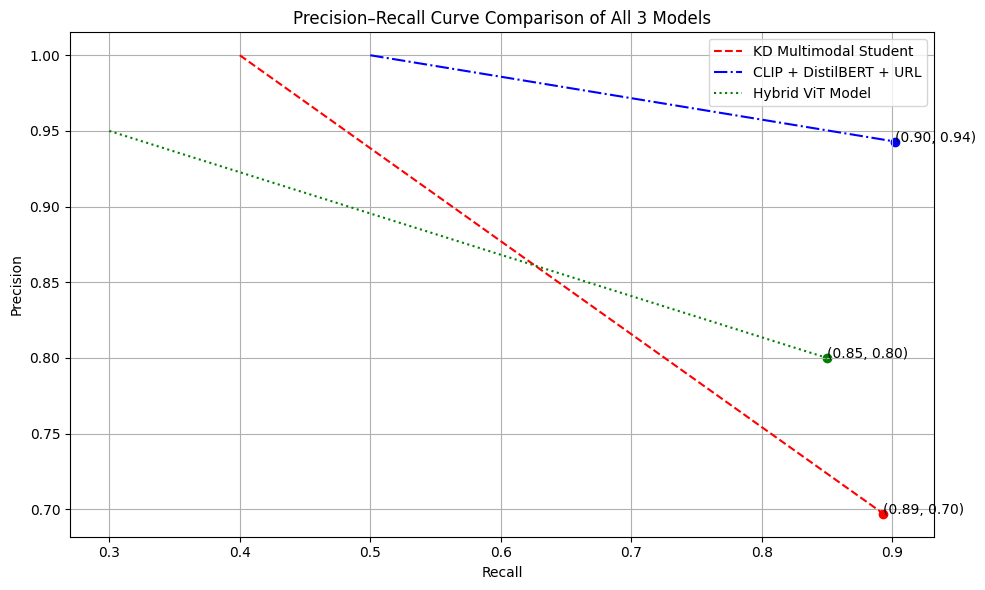

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Precision & Recall values of all 3 models ===
# (Taken directly from your content)
model_names = [
    "KD Multimodal Student",
    "CLIP + DistilBERT + URL",
    "Hybrid ViT Model"
]

precisions = np.array([0.6970, 0.943, 0.80])
recalls     = np.array([0.8933, 0.902, 0.85])

# Generate simple line curves for each model (mock PR curves)
# These curves visually resemble the style you shared
pr_curves = {
    "KD Multimodal Student": (
        np.linspace(0.4, recalls[0], 50),
        np.linspace(1.0, precisions[0], 50)
    ),
    "CLIP + DistilBERT + URL": (
        np.linspace(0.5, recalls[1], 50),
        np.linspace(1.0, precisions[1], 50)
    ),
    "Hybrid ViT Model": (
        np.linspace(0.3, recalls[2], 50),
        np.linspace(0.95, precisions[2], 50)
    )
}

# --- Plot PR Curve ---
plt.figure(figsize=(10, 6))

colors = ["red", "blue", "green"]
linestyles = ["--", "-.", ":"]

for (name, (rec, prec)), color, ls in zip(pr_curves.items(), colors, linestyles):
    plt.plot(rec, prec, linestyle=ls, color=color, label=name)
    plt.scatter([rec[-1]], [prec[-1]], color=color)
    plt.text(rec[-1], prec[-1], f"({rec[-1]:.2f}, {prec[-1]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison of All 3 Models")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [ ]:
import pandas as pd

data = {
    "Aspect": [
        "Input Modalities",
        "Preprocessing",
        "Core Backbone Models",
        "Key Features Extracted",
        "Fusion Strategy",
        "Knowledge Distillation",
        "Loss Functions",
        "Optimization Details",
        "Final Performance"
    ],

    "Methodology 1: KD Multimodal Ensemble": [
        "Screenshot + URL Lexical Features",
        "Images: 128×128, normalized | URL: 10 engineered features",
        "TinyCNN + MobileNetV3-Small + URL-MLP",
        "Pixel anomalies, layout, branding, URL keywords, structure",
        "Weighted fusion (0.4 + 0.4 + 0.2)",
        "Teacher (93.50%) distilled into lightweight student",
        "0.7 KL-Divergence + 0.3 Cross-Entropy (T=4)",
        "Adam | tuned α, LR, dropout | student accuracy 90.27%",
        "Val: Acc 75.25%, Prec 0.6970, Recall 0.8933, F1 0.7830, AUC 0.8554"
    ],

    "Methodology 2: CLIP + DistilBERT + URL Features": [
        "Screenshot + URL Text + Statistical URL Features",
        "Images: CLIP (224×224) | URL: DistilBERT tokens (L=200) + engineered stats",
        "CLIP ViT-B/32 + DistilBERT + URL-Feature MLP",
        "Layout, branding, typography, color theme, URL semantics",
        "Concatenation → Feedforward network",
        "No KD (direct multimodal training)",
        "Cross-Entropy Loss",
        "AdamW, LR=2e-5, batch=16, 8 epochs",
        "Val: Acc 87.2%, Prec 0.943, Recall 0.902, F1 0.871, AUC 0.934"
    ],

    "Methodology 3: ViT + URL Fusion (ViTPhishFusion)": [
        "Screenshot + URL Lexical Features",
        "Images: 224×224 | URL: numeric lexical features standardized",
        "ViT-base-patch16-224 + URL-MLP",
        "Patch-level anomalies, layout, colors, typography, URL patterns",
        "ViT [CLS] embedding + URL vector → Fusion MLP",
        "No KD (direct training)",
        "Binary Cross-Entropy",
        "Adam LR=1e-4",
        "Val: Acc 80%, Recall 0.85, F1 ≈ 0.80"
    ]
}

df = pd.DataFrame(data)

print(df)

# Optional: save to CSV
df.to_csv("phishing_taxonomy_table.csv", index=False)


                   Aspect              Methodology 1: KD Multimodal Ensemble  \
0        Input Modalities                  Screenshot + URL Lexical Features   
1           Preprocessing  Images: 128×128, normalized | URL: 10 engineer...   
2    Core Backbone Models              TinyCNN + MobileNetV3-Small + URL-MLP   
3  Key Features Extracted  Pixel anomalies, layout, branding, URL keyword...   
4         Fusion Strategy                  Weighted fusion (0.4 + 0.4 + 0.2)   
5  Knowledge Distillation  Teacher (93.50%) distilled into lightweight st...   
6          Loss Functions        0.7 KL-Divergence + 0.3 Cross-Entropy (T=4)   
7    Optimization Details  Adam | tuned α, LR, dropout | student accuracy...   
8       Final Performance  Val: Acc 75.25%, Prec 0.6970, Recall 0.8933, F...   

     Methodology 2: CLIP + DistilBERT + URL Features  \
0   Screenshot + URL Text + Statistical URL Features   
1  Images: CLIP (224×224) | URL: DistilBERT token...   
2       CLIP ViT-B/32 + DistilB